In [1]:


from loadPressureData import loadPressureData, matlab_datenum_to_datetime64
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from BulkWaveStats import detide, Spp_to_Seta, sig_wave_height
from scipy.signal import spectrogram
from eta_f import compute_eta_f



This notebook follows the computations performed on Becker(2014) *Water Level Effects on breaking wave setup for Pacific Island fringing reefs*

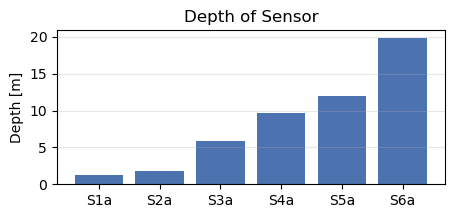

In [2]:
# need to decide where the reef flat/reef face is 
labels = ['S1a', 'S2a', 'S3a', 'S4a', 'S5a', 'S6a']
depths = [1.3, 1.74, 5.90, 9.64, 11.95, 19.9]

fig, ax = plt.subplots(figsize=(5, 2))
ax.bar(labels, depths, color="#4C72B0")
ax.set_ylabel("Depth [m]")
ax.set_title("Depth of Sensor")
ax.grid(axis="y", alpha=0.3)
plt.show()

since sensor 1 and 2 are ~same depth, i'm going to assumer that sensor 3 is the end of the reef face and sensor 6 is the "offshore" sensor but will talk to mark about that. 

In [3]:
### ------------------ LOAD AND DETIDE DATA -------------------- ###

## ----- Sensor 1 (NEARSHORE)----- ##
bursts1 = loadPressureData(Path("data/MoA18411.mat"))
t1, h1, p1 = bursts1.time, bursts1.depth_m, bursts1.pressure_pa
# detide
tide1, p1_detide, p1_raw = detide(p1, t1, LAT = 21.58055556)

## ----- Sensor 4 (REEF FACE)----- ##
bursts4 = loadPressureData(Path("data/MoA48411.mat"))
t4, h4, p4 = bursts4.time, bursts4.depth_m, bursts4.pressure_pa
# detide
tide4, p4_detide, p4_raw = detide(p4, t4, LAT = 21.58055556)

## ----- Sensor 6 (OFFSHORE)----- ##
bursts6 = loadPressureData(Path("data/MoA68411.mat"))
t6, h6, p6 = bursts6.time, bursts6.depth_m, bursts6.pressure_pa
# detide
tide6, p6_detide, p6_raw = detide(p6, t6, LAT = 21.58055556)

prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.
prep/calcs ... done.


Text(0.5, 1.0, 'detided elevation autspectra with nperseg=131072')

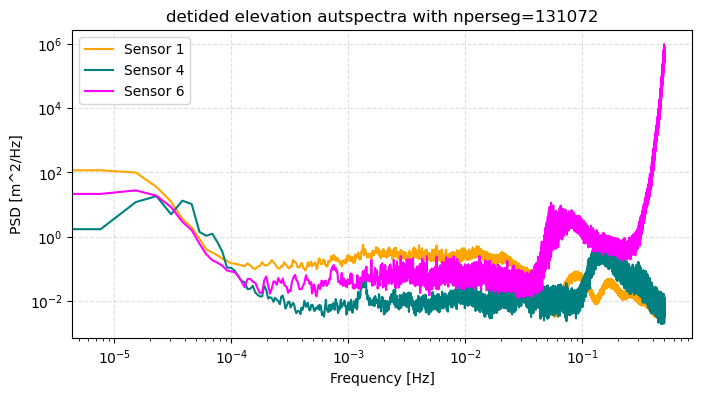

In [5]:
# INPUT VALUES
fs = 1
nperseg = 131072 # 2 hr windows
noverlap = nperseg * 0.75 # 75% overlap

# compute pressure spectra ---> convert to sfc elevation spectra
freqs1, t1_spec, Spp1 = spectrogram(p1_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta1, t_eta1, h_eta1 = Spp_to_Seta(Spp1, freqs1, t1_spec, t1, h1)

freqs4, t4_spec, Spp4 = spectrogram(p4_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta4, t_eta4, h_eta4 = Spp_to_Seta(Spp4, freqs4, t4_spec, t4, h4)

freqs6, t6_spec, Spp6 = spectrogram(p6_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta6, t_eta6, h_eta6 = Spp_to_Seta(Spp6, freqs6, t6_spec, t6, h6)

## ------- Autospectra plot ------ ##

autospec1 = np.nanmean(Seta1, axis=1)  
autospec4 = np.nanmean(Seta4, axis=1)  
autospec6 = np.nanmean(Seta6, axis=1)  

fig, ax = plt.subplots(figsize=(8,4))

ax.loglog(freqs1, autospec1, color='orange', label = 'Sensor 1')
ax.loglog(freqs4, autospec4, color='teal', label = 'Sensor 4')
ax.loglog(freqs6, autospec6, color='magenta', label = 'Sensor 6')
#ax.set_xlim(None,0.08)
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('PSD [m^2/Hz]')
ax.legend()
ax.set_title('detided elevation autspectra with nperseg={}'.format(nperseg))


In [7]:
# INPUT VALUES
fs = 1
nperseg = 7200 # 2 hr windows
noverlap = nperseg * 0.75 # 75% overlap

# compute pressure spectra ---> convert to sfc elevation spectra
freqs1, t1_spec, Spp1 = spectrogram(p1_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta1, t_eta1, h_eta1 = Spp_to_Seta(Spp1, freqs1, t1_spec, t1, h1)

freqs4, t4_spec, Spp4 = spectrogram(p4_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta4, t_eta4, h_eta4 = Spp_to_Seta(Spp4, freqs4, t4_spec, t4, h4)

freqs6, t6_spec, Spp6 = spectrogram(p6_detide, fs=fs, window = 'hann', nperseg = nperseg, noverlap = nperseg/2, detrend = 'linear', scaling = 'density',mode='psd', )
Seta6, t_eta6, h_eta6 = Spp_to_Seta(Spp6, freqs6, t6_spec, t6, h6)

In [ ]:
ds_etaf = compute_eta_f(Seta4, freqs4, t4_spec, t4, h4, band=(0.033, 0.35))
ds_etaf["eta_f"].plot()

NameError: name 'ds_eta4' is not defined

In [9]:
ds_etaf

<xarray.Dataset> Size: 816B
Dimensions:  (time: 17)
Coordinates:
  * time     (time) datetime64[ns] 136B 2007-12-14T18:12:16 ... 2007-12-26T21...
Data variables:
    eta_f    (time) float64 136B nan nan nan nan nan nan ... nan nan nan nan nan
    H_rms    (time) float64 136B 0.4248 0.4486 0.3594 ... 0.7474 0.5844 0.3991
    k_f      (time) float64 136B 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    h_f      (time) float64 136B -5.941 -5.893 -5.875 ... -6.522 -6.416 -6.408
    f        (time) float64 136B 0.1996 0.1989 0.1959 ... 0.1705 0.18 0.1792
Attributes:
    equation:  eta_f = -(H_f^2 k_f) / (8 sinh(2 k_f h_f))
    band:      (0.033, 0.35)

Text(0, 0.5, 'height (m)')

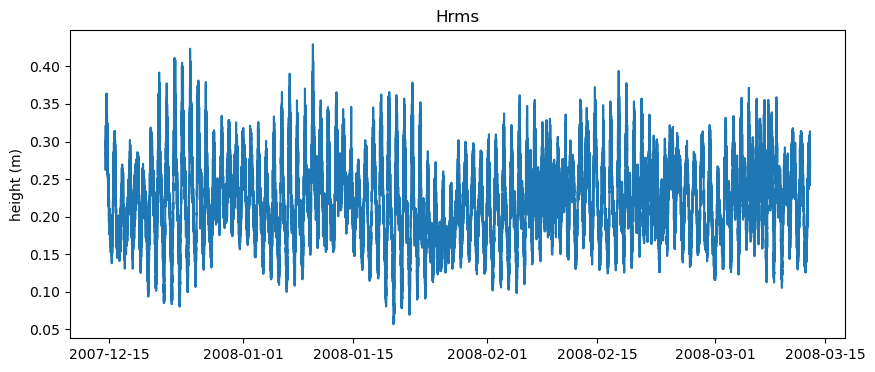

In [110]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(t_center, Hrms)
ax.set_title('Hrms')
ax.set_ylabel('height (m)')

#### Compute RMS Wave Height, H

In [85]:
band = (freqs >= 0.033) & (freqs <= 0.35)
m0 = np.trapz(Seta1[band, :], freqs[band], axis=0)          # variance per window
Hrms = 2 * np.sqrt(2 * np.maximum(m0, 0.0) )#np.max to ensure no negative values

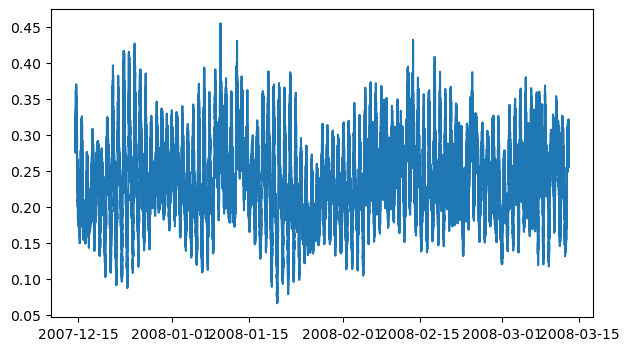

In [91]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_eta1, Hrms)

In [96]:
eta_idx = pd.to_datetime(t1)  # 1 Hz index
eta_band_std = (
    pd.Series(eta_band, index=eta_idx)
    .rolling(window=nperseg, center=True, min_periods=nperseg//2)
    .std()
)

t_eta_idx = pd.to_datetime(t_eta1).round("S")  # align with 1 s grid
Hrms_time = 2.0 * np.sqrt(2.0) * (
    eta_band_std.reindex(t_eta_idx, method="nearest", tolerance="1s")
).to_numpy()


/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_93208/2526224342.py:8: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  t_eta_idx = pd.to_datetime(t_eta1).round("S")  # align with 1 s grid
